Dataset:
    Day   outlook  temp humidity  windy play
0     1     sunny   hot     high  False   no
1     2     sunny   hot     high   True   no
2     3  overcast   hot     high  False  yes
3     4     rainy  mild     high  False  yes
4     5     rainy  cool   normal  False  yes
5     6     rainy  cool   normal   True   no
6     7  overcast  cool   normal   True  yes
7     8     sunny  mild     high  False   no
8     9     sunny  cool   normal  False  yes
9    10     rainy  mild   normal  False  yes
10   11     sunny  mild   normal   True  yes
11   12  overcast  mild     high   True  yes
12   13  overcast   hot   normal  False  yes
13   14     rainy  mild     high   True   no

Accuracy: 0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

          no       0.50      1.00      0.67         1
         yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67 

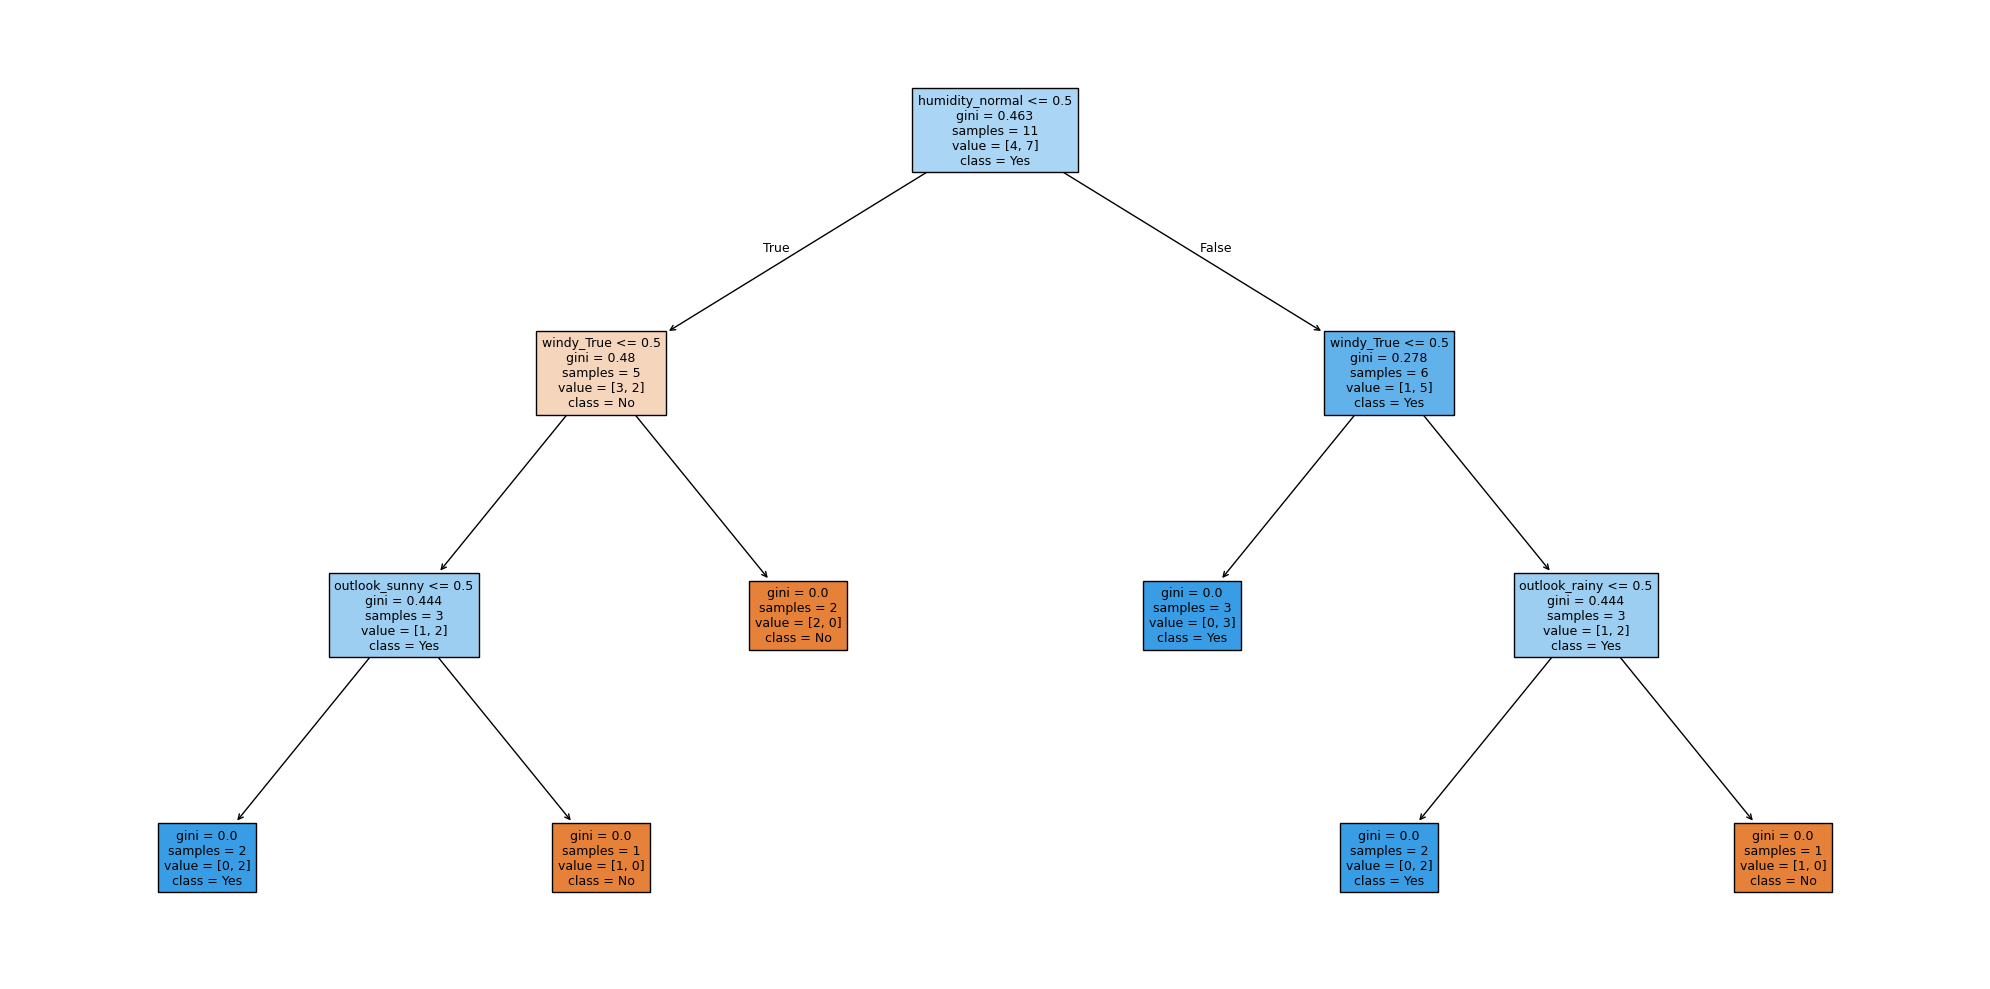


Saved tree image as weather_decision_tree.png


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv('weather_playing_cricket.csv')

print("Dataset:")
print(df)

# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# ============================================================
# 3. ENCODE CATEGORICAL COLUMNS
# ============================================================

df_encoded = pd.get_dummies(
    df,
    columns=['outlook', 'temp', 'humidity', 'windy'],
    drop_first=True
)

# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df_encoded.drop(columns=['play', 'Day'])
y = df_encoded['play']

# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# 6. CREATE DECISION TREE
# ============================================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 7. PREDICTION
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 8. EVALUATION
# ============================================================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 9. DISPLAY DECISION TREE
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    fontsize=9
)

plt.tight_layout()

plt.savefig('weather_decision_tree.png', dpi=150)

plt.show()

print("\nSaved tree image as weather_decision_tree.png")